# Practica: Self-Organizing Maps (SOM) con MNIST

### **Miembros:** Junjing Wu, Yixuan Lu, Xianye Lin

---

## Objetivo
Responder a las siguientes preguntas:
1. Puede un SOM aprender los datos del MNIST?
2. Responde cada neurona a un unico digito?
3. Que numeros se parecen mas entre si? Se parece mas un 5 a un 8 o a un 4?

**Para ello:**
- Entrenar un SOM con el dataset MNIST usando la clase `som` suministrada (Python 3.12)
- Analizar los resultados:
  - Usar `draw_map` con `labels` para ver a que clase responde cada neurona y en que porcentaje
  - Pintar el prototipo de cada clase

---

### Que es un SOM?
Un **Self-Organizing Map (SOM)**, o mapa autoorganizado de Kohonen, es una red neuronal de aprendizaje **no supervisado** que proyecta datos de alta dimension sobre una rejilla 2D preservando su estructura topologica: dos muestras similares en el espacio original acabaran representadas por neuronas cercanas en el mapa.

### Para que sirve?
Los SOMs tienen tres aplicaciones principales. Como herramienta de **clustering** agrupan muestras similares sin necesitar etiquetas. Como tecnica de **reduccion de dimensionalidad** comprimen la informacion manteniendo las relaciones de vecindad. Y como mecanismo de **visualizacion** traducen espacios de cientos de dimensiones en un mapa 2D interpretable a simple vista.

### Como funciona?
El entrenamiento sigue tres fases que se repiten epoca a epoca. Primero, cada muestra **compite** por activar la neurona mas parecida a ella (la BMU, *Best Matching Unit*). Segundo, la BMU y sus vecinas **cooperan** actualizando sus pesos para acercarse a esa muestra. Tercero, tanto la tasa de aprendizaje como el radio de vecindad **decaen** progresivamente, estabilizando el mapa con el paso del tiempo.

### Complejidad
El coste es **O(N x M x E)** --- proporcional al numero de muestras (N), neuronas (M) y epocas (E).

---

**Sobre el dataset:** Se emplea `fetch_openml('mnist_784')`, el MNIST original con 70 000 imagenes de 28x28 px (784 dimensiones por muestra). Esta eleccion produce resultados mas ricos y comparables con la literatura.

In [1]:
from som import *          # clase SOM suministrada (Python 3.12)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
from collections import Counter
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## 1. Cargar y preparar los datos

In [2]:
# Cargamos el MNIST completo (70 000 imagenes de 28x28 px = 784 dimensiones)
mnist  = fetch_openml('mnist_784', version=1, as_frame=False)
X_full = mnist.data      # (70000, 784)
y_full = mnist.target    # strings '0'..'9'

print(f"Dataset MNIST completo:")
print(f"  Muestras       : {X_full.shape[0]}")
print(f"  Caracteristicas: {X_full.shape[1]}")
print(f"  Clases         : {np.unique(y_full)}")

# Subconjunto de 12 000 muestras para mantener tiempos razonables
N = 12_000
X = X_full[:N].astype(float)
y = y_full[:N]               # strings --- la clase som trabaja con strings

# Normalizacion al rango [0, 1]
X_scaled = X / 255.0

print(f"\nSubconjunto de entrenamiento:")
print(f"  Muestras usadas: {N}")
print(f"  Rango tras normalizar: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
print(f"  Distribucion de clases: {np.bincount(y.astype(int))}")

Dataset MNIST completo:
  Muestras       : 70000
  Caracteristicas: 784
  Clases         : ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']

Subconjunto de entrenamiento:
  Muestras usadas: 12000
  Rango tras normalizar: [0.00, 1.00]
  Distribucion de clases: [1206 1351 1176 1228 1184 1048 1208 1279 1127 1193]


## 2. Entrenar el SOM

### Eleccion del tamano del mapa y los parametros

En algoritmos clasicos como **K-Means**, definimos de antemano el numero de clusters. En un SOM el mapa se organiza de forma que neuronas cercanas respondan a patrones similares, por lo que el tamano es una eleccion de diseno clave:

- **Demasiado pequeno** (p.ej. 3x3): menos neuronas que clases -> mezcla de digitos.
- **Demasiado grande** (p.ej. 100x100): muchas neuronas vacias, dificil de interpretar.

Usamos un mapa **10x10** (100 neuronas) como punto de partida razonable para 10 clases, con margen para capturar variaciones de escritura dentro de cada digito. Cada neurona tendra un vector de pesos de 784 dimensiones, visualizable como una imagen 28x28.

| Parametro | Efecto |
|-----------|--------|
| `alpha0`  | Tasa de aprendizaje inicial --- valores altos aceleran pero inestabilizan |
| `alphaf`  | Tasa de aprendizaje final --- controla el ajuste fino al final |
| `sigmaf`  | Radio de vecindad final --- cuanto se afina la especializacion |
| `epochs`  | Mas epocas -> mapa mas estable, pero mayor coste computacional |

In [3]:
som = SOM(10, 10)          # mapa 10x10, metrica euclidea por defecto

som.train(
    X_scaled,
    epochs  = 100,
    alpha0  = 0.8,    # tasa de aprendizaje inicial
    alphaf  = 0.05,   # tasa de aprendizaje final
    sigmaf  = 0.4,    # radio de vecindad final
    trace   = 10,     # imprime progreso cada 10 epocas
    verbose = 1
)

print(f"\nTopologia del SOM : {som.N} x {som.M}")
print(f"Total de neuronas : {som.N * som.M}")

ite:  10, mean_qe: 7.852; max_qe: 12.568; d: 1.294; alpha: 0.73; sigma: 8.51; lapse: 268.42
ite:  20, mean_qe: 7.555; max_qe: 12.530; d: 1.656; alpha: 0.65; sigma: 6.72; lapse: 257.26
ite:  30, mean_qe: 7.273; max_qe: 12.402; d: 2.009; alpha: 0.58; sigma: 5.10; lapse: 260.47
ite:  40, mean_qe: 6.976; max_qe: 11.812; d: 2.344; alpha: 0.50; sigma: 3.76; lapse: 256.88
ite:  50, mean_qe: 6.649; max_qe: 11.383; d: 2.937; alpha: 0.42; sigma: 2.71; lapse: 261.38
ite:  60, mean_qe: 6.280; max_qe: 10.633; d: 3.176; alpha: 0.35; sigma: 1.91; lapse: 254.91
ite:  70, mean_qe: 5.915; max_qe: 10.287; d: 3.489; alpha: 0.28; sigma: 1.32; lapse: 252.82
ite:  80, mean_qe: 5.615; max_qe: 10.430; d: 3.631; alpha: 0.20; sigma: 0.90; lapse: 257.10
ite:  90, mean_qe: 5.395; max_qe: 10.017; d: 4.088; alpha: 0.12; sigma: 0.60; lapse: 259.49
ite: 100, mean_qe: 5.186; max_qe: 9.690; d: 4.743; alpha: 0.05; sigma: 0.40; lapse: 251.44
ite: 100, mean_qe: 5.186; max_qe: 9.690; d: 4.743; alpha: 0.05; sigma: 0.40; laps

## 3. Analisis de resultados: `draw_map` con labels

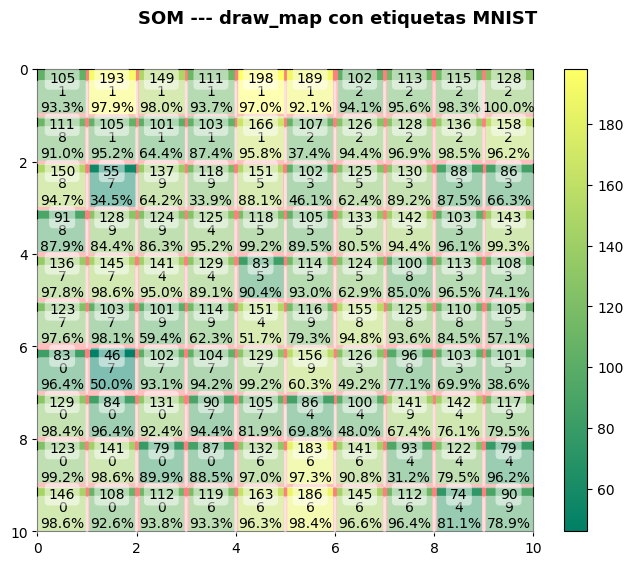

In [7]:
# draw_map muestra para cada neurona la etiqueta dominante,
# el porcentaje de acierto y las fronteras entre regiones
labels_map = som.summarize_distribution(X_scaled, y)  # convierte a matriz (10×10)
som.draw_map(X_scaled, labels=labels_map, textual=False)
plt.suptitle('SOM --- draw_map con etiquetas MNIST', fontsize=13, weight='bold')
plt.show()

## 4. Visualizar el mapa con etiquetas y confianza

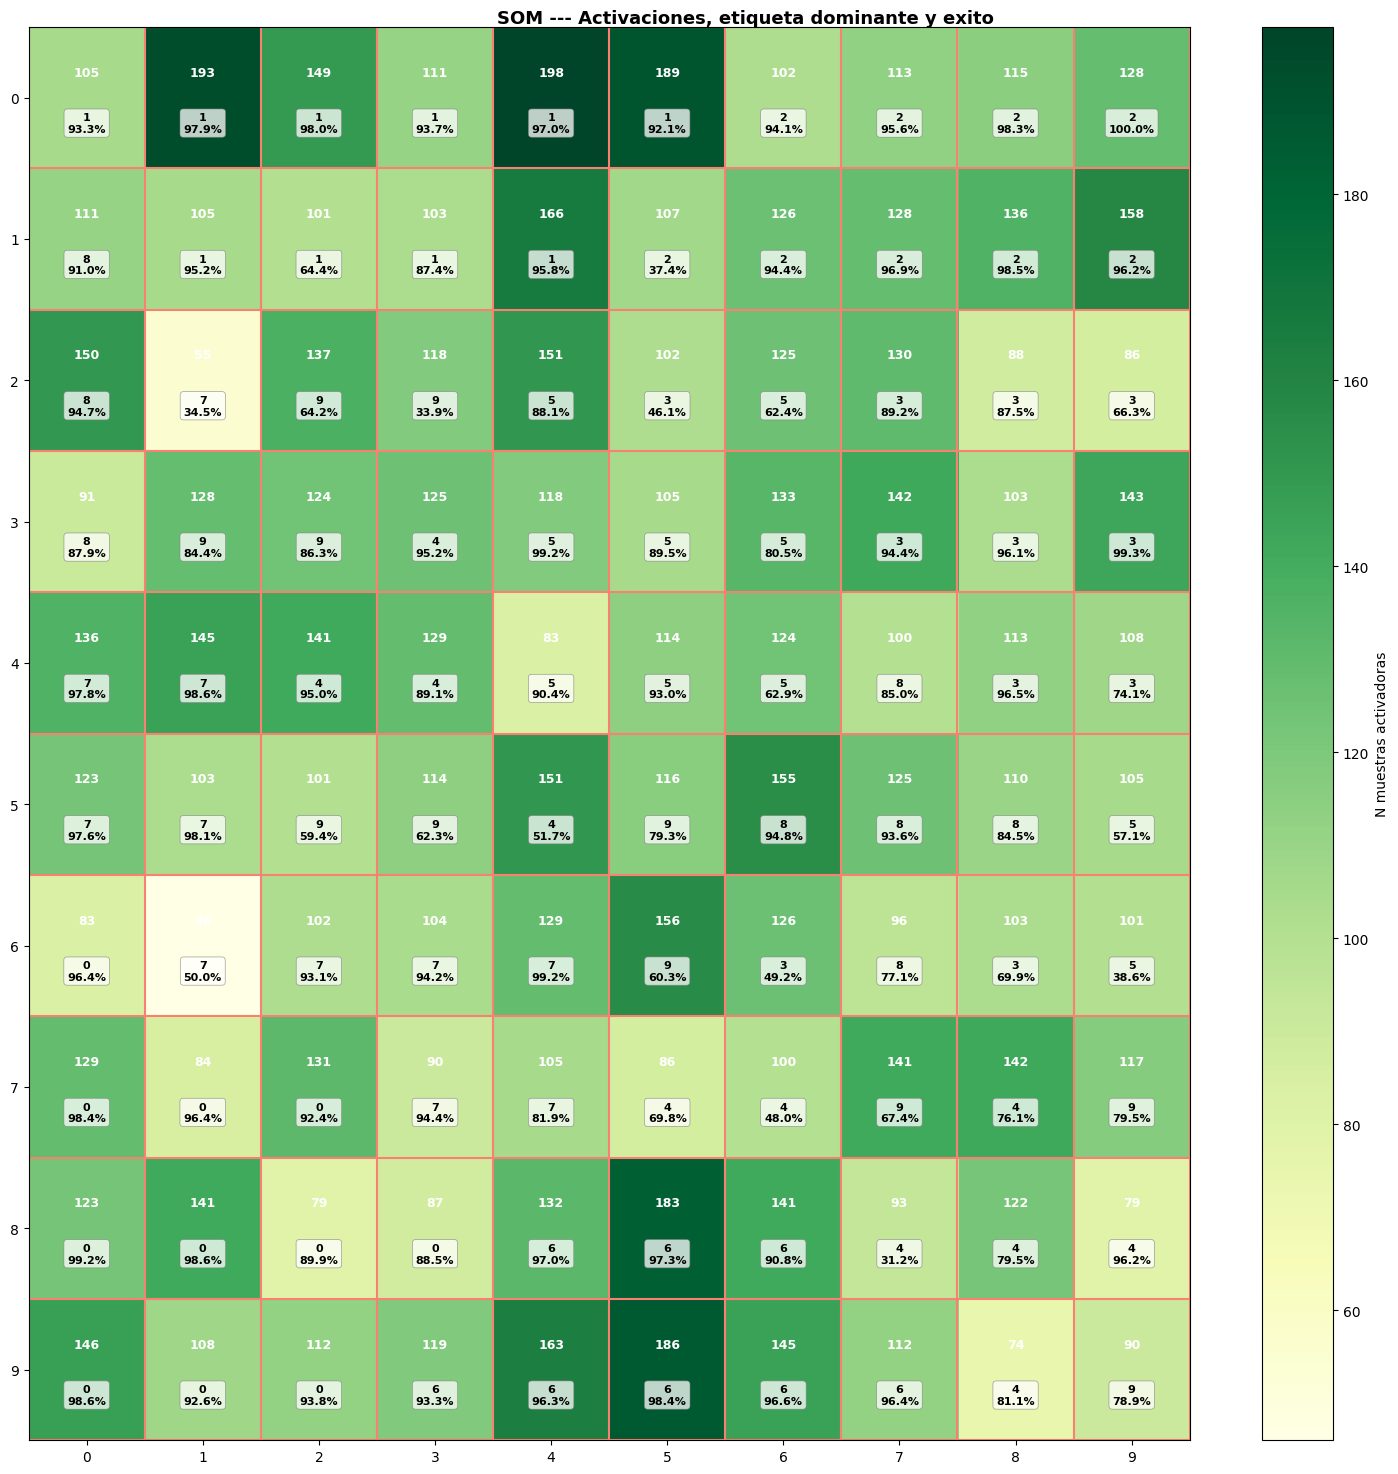


   Neurona   Activaciones   Label dom.  Acierto
---------------------------------------------------
  (0,0)            105            1       93.3%
  (0,1)            193            1       97.9%
  (0,2)            149            1       98.0%
  (0,3)            111            1       93.7%
  (0,4)            198            1       97.0%
  (0,5)            189            1       92.1%
  (0,6)            102            2       94.1%
  (0,7)            113            2       95.6%
  (0,8)            115            2       98.3%
  (0,9)            128            2      100.0%
  (1,0)            111            8       91.0%
  (1,1)            105            1       95.2%
  (1,2)            101            1       64.4%
  (1,3)            103            1       87.4%
  (1,4)            166            1       95.8%
  (1,5)            107            2       37.4%
  (1,6)            126            2       94.4%
  (1,7)            128            2       96.9%
  (1,8)            136            2

In [8]:
# Estadisticas por neurona usando predict() de la clase som
winners_raw  = som.predict(X_scaled)  # lista de tuplas (fila, col)
winners_flat = np.array([int(w[0]) * som.M + int(w[1]) for w in winners_raw])

neuron_labels_list = [[] for _ in range(som.N * som.M)]
for i, w in enumerate(winners_flat):
    neuron_labels_list[w].append(str(y[i]))

neuron_stats = []
for lbs in neuron_labels_list:
    if len(lbs) == 0:
        neuron_stats.append({'count': 0, 'label': '', 'success_%': 0.0})
    else:
        cnt = Counter(lbs)
        dominant, dom_count = cnt.most_common(1)[0]
        success = 100.0 * dom_count / len(lbs)
        neuron_stats.append({'count': len(lbs), 'label': dominant, 'success_%': success})

stats_grid = np.array(neuron_stats).reshape(som.N, som.M)

# Heatmap de activaciones
counts_arr = np.array([[stats_grid[i,j]['count']
                        for j in range(som.M)] for i in range(som.N)], dtype=float)

fig, ax = plt.subplots(figsize=(som.M * 1.5, som.N * 1.5))
fig.suptitle('SOM --- Activaciones, etiqueta dominante y exito', fontsize=13, weight='bold')

im = ax.imshow(counts_arr, cmap='YlGn', aspect='auto',
               vmin=counts_arr[counts_arr > 0].min() if (counts_arr > 0).any() else 0,
               vmax=counts_arr.max())
plt.colorbar(im, ax=ax, label='N muestras activadoras')

for i in range(som.N):
    for j in range(som.M):
        s = stats_grid[i, j]
        if s['count'] == 0:
            continue
        ax.text(j, i - 0.18, str(s['count']),
                ha='center', va='center', fontsize=9, color='white', weight='bold')
        bbox_props = dict(boxstyle='round,pad=0.3',
                          facecolor='white', alpha=0.75, edgecolor='gray', lw=0.5)
        ax.text(j, i + 0.18, f"{s['label']}\n{s['success_%']:.1f}%",
                ha='center', va='center', fontsize=8, color='black', weight='bold',
                bbox=bbox_props)

for x_ in np.arange(-0.5, som.M, 1): ax.axvline(x_, color='salmon', lw=1.5)
for y_ in np.arange(-0.5, som.N, 1): ax.axhline(y_, color='salmon', lw=1.5)
ax.set_xticks(range(som.M)); ax.set_yticks(range(som.N))
plt.tight_layout(); plt.show()

# Tabla neurona a neurona con accuracy ponderada
print(f"\n{'Neurona':>10} {'Activaciones':>14} {'Label dom.':>12} {'Acierto':>8}")
print('---' * 17)
total_ok = total_n = 0
for i in range(som.N):
    for j in range(som.M):
        s = stats_grid[i, j]
        if s['count'] > 0:
            print(f"  ({i},{j})     {s['count']:>10}     {s['label']:>8}     {s['success_%']:>6.1f}%")
            total_ok += (s['success_%'] / 100) * s['count']
            total_n  += s['count']
print('---' * 17)
accuracy_ponderada = (total_ok / total_n) * 100
print(f"{'Accuracy Media Ponderada (Global)':>38}: {accuracy_ponderada:>6.1f}%")

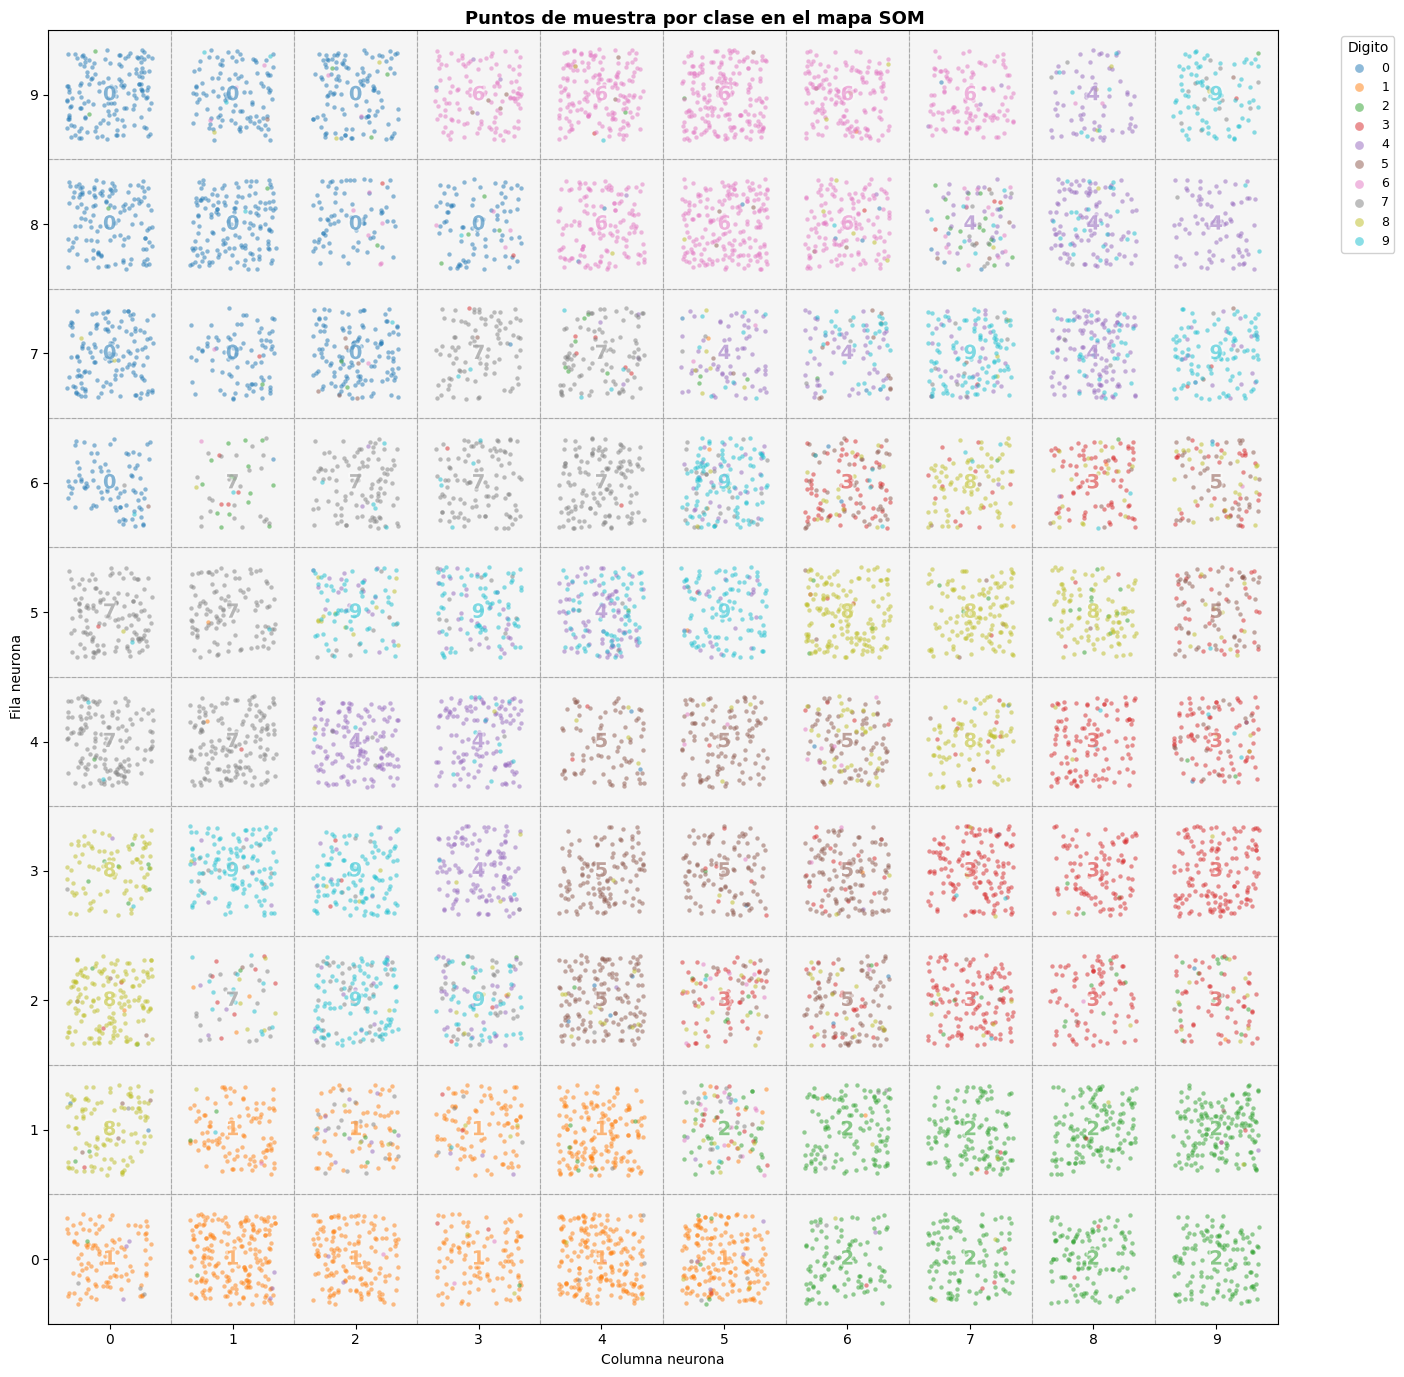

In [9]:
DIGIT_COLORS = plt.cm.get_cmap('tab10', 10)
y_int = y.astype(int)

jitter = 0.35
rows_w = np.array([int(w[0]) for w in winners_raw])
cols_w = np.array([int(w[1]) for w in winners_raw])
x_jit  = cols_w + np.random.uniform(-jitter, jitter, size=len(winners_raw))
y_jit  = rows_w + np.random.uniform(-jitter, jitter, size=len(winners_raw))

fig, ax = plt.subplots(figsize=(som.M * 1.4, som.N * 1.4))
fig.suptitle('Puntos de muestra por clase en el mapa SOM', fontsize=13, weight='bold')

for i in range(som.N):
    for j in range(som.M):
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                     facecolor='whitesmoke', edgecolor='lightgray', lw=0.8, zorder=0))

for digit in range(10):
    mask = y_int == digit
    ax.scatter(x_jit[mask], y_jit[mask], color=DIGIT_COLORS(digit),
               s=10, alpha=0.5, linewidths=0, label=str(digit), zorder=2)

for i in range(som.N):
    for j in range(som.M):
        s = stats_grid[i, j]
        if s['count'] > 0:
            txt = ax.text(j, i, s['label'], ha='center', va='center',
                          fontsize=14, weight='black',
                          color=DIGIT_COLORS(int(s['label'])), zorder=3, alpha=0.4)
            txt.set_path_effects([pe.withStroke(linewidth=3, foreground='white')])

for x_ in np.arange(-0.5, som.M, 1): ax.axvline(x_, color='gray', lw=0.8, ls='--', alpha=0.5)
for y_ in np.arange(-0.5, som.N, 1): ax.axhline(y_, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_xlim(-0.5, som.M - 0.5); ax.set_ylim(-0.5, som.N - 0.5)
ax.set_xticks(range(som.M)); ax.set_yticks(range(som.N))
ax.set_xlabel('Columna neurona'); ax.set_ylabel('Fila neurona')
ax.legend(title='Digito', loc='upper right', bbox_to_anchor=(1.1, 1),
          fontsize=9, markerscale=2, framealpha=0.9)
plt.tight_layout(); plt.show()

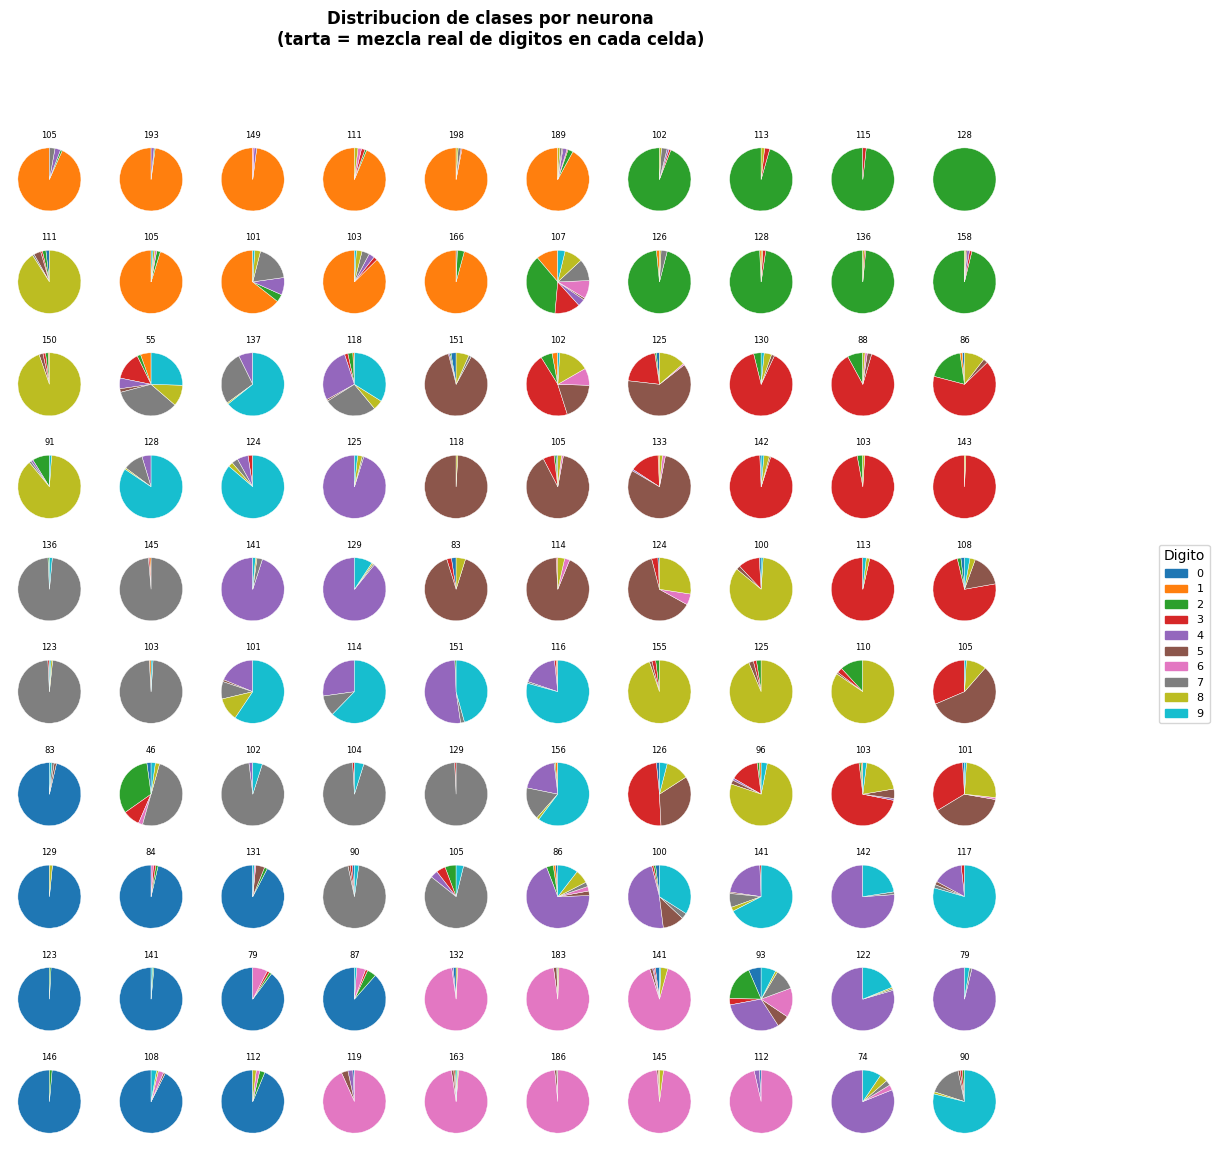

In [10]:
# Distribucion de clases por neurona
neuron_label_ints = [[] for _ in range(som.N * som.M)]
for idx, w in enumerate(winners_flat):
    neuron_label_ints[w].append(int(y[idx]))

fig_b, axes_b = plt.subplots(som.N, som.M, figsize=(som.M * 1.3, som.N * 1.3))
fig_b.suptitle('Distribucion de clases por neurona\n'
               '(tarta = mezcla real de digitos en cada celda)',
               fontsize=12, weight='bold')

for i in range(som.N):
    for j in range(som.M):
        ax  = axes_b[i, j]
        lbs = neuron_label_ints[i * som.M + j]
        ax.axis('off')
        if not lbs:
            continue
        cnt    = Counter(lbs)
        digits = sorted(cnt.keys())
        sizes  = [cnt[d] for d in digits]
        colors = [DIGIT_COLORS(d) for d in digits]
        ax.pie(sizes, colors=colors, startangle=90,
               wedgeprops=dict(linewidth=0.3, edgecolor='white'))
        ax.set_title(str(len(lbs)), fontsize=6, pad=1)

handles = [mpatches.Patch(color=DIGIT_COLORS(d), label=str(d)) for d in range(10)]
fig_b.legend(handles=handles, title='Digito',
             bbox_to_anchor=(1.01, 0.5), loc='center left', fontsize=8)
plt.subplots_adjust(wspace=0.1, hspace=0.3)
plt.show()

## 5. Analisis estadistico: Responde cada neurona a un unico digito?

In [11]:
purity_scores     = []
neurons_per_digit = {i: [] for i in range(10)}

for i in range(som.N):
    for j in range(som.M):
        s = stats_grid[i, j]
        if s['count'] == 0:
            continue
        purity = s['success_%'] / 100.0
        purity_scores.append(purity)
        neurons_per_digit[int(s['label'])].append((i, j))

purity_scores = np.array(purity_scores)

print('ANALISIS DE PUREZA:')
print(f'  Pureza promedio       : {purity_scores.mean():.2%}')
print(f'  Pureza minima         : {purity_scores.min():.2%}')
print(f'  Pureza maxima         : {purity_scores.max():.2%}')
print(f'  Desviacion estandar   : {purity_scores.std():.2%}')
print(f'\n  Neuronas con pureza > 80% : {(purity_scores > 0.8).sum()} / {len(purity_scores)}')
print(f'  Neuronas con pureza > 90% : {(purity_scores > 0.9).sum()} / {len(purity_scores)}')
print(f'  Neuronas con pureza = 100%: {(purity_scores == 1.0).sum()} / {len(purity_scores)}')
print('\nNEURONAS ESPECIALIZADAS POR DIGITO:')
for digit in range(10):
    print(f'  Digito {digit}: {len(neurons_per_digit[digit])} neuronas')

ANALISIS DE PUREZA:
  Pureza promedio       : 83.84%
  Pureza minima         : 31.18%
  Pureza maxima         : 100.00%
  Desviacion estandar   : 17.81%

  Neuronas con pureza > 80% : 71 / 100
  Neuronas con pureza > 90% : 55 / 100
  Neuronas con pureza = 100%: 1 / 100

NEURONAS ESPECIALIZADAS POR DIGITO:
  Digito 0: 11 neuronas
  Digito 1: 10 neuronas
  Digito 2: 9 neuronas
  Digito 3: 11 neuronas
  Digito 4: 11 neuronas
  Digito 5: 10 neuronas
  Digito 6: 8 neuronas
  Digito 7: 11 neuronas
  Digito 8: 8 neuronas
  Digito 9: 11 neuronas


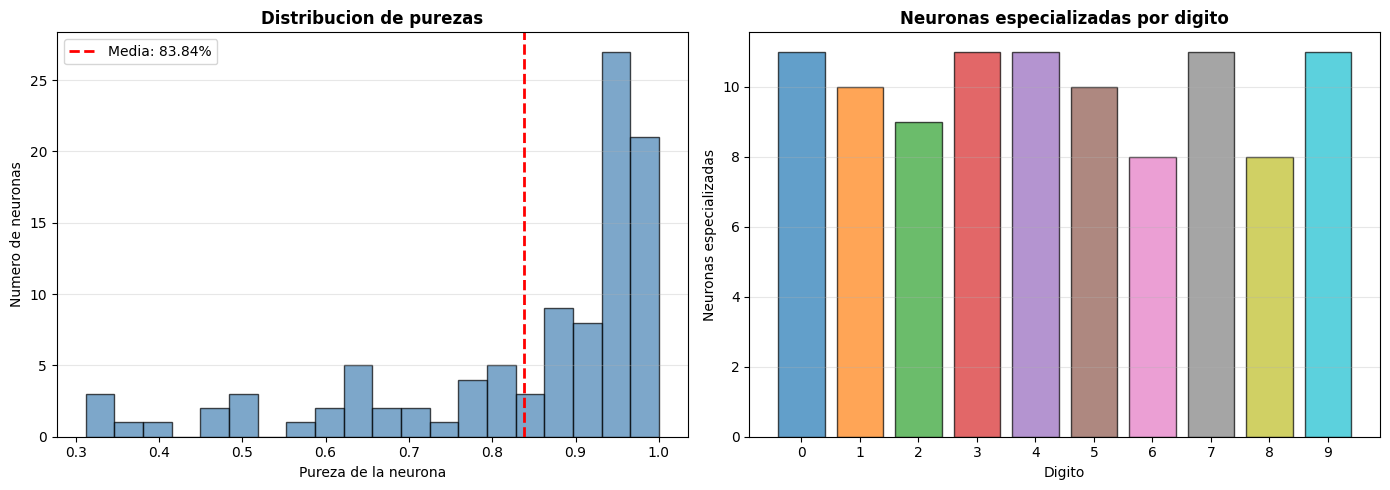

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(purity_scores, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(purity_scores.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Media: {purity_scores.mean():.2%}')
axes[0].set_xlabel('Pureza de la neurona')
axes[0].set_ylabel('Numero de neuronas')
axes[0].set_title('Distribucion de purezas', fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

colors_tab = plt.cm.tab10(np.arange(10))
axes[1].bar(range(10), [len(neurons_per_digit[i]) for i in range(10)],
            color=colors_tab, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Digito'); axes[1].set_ylabel('Neuronas especializadas')
axes[1].set_title('Neuronas especializadas por digito', fontweight='bold')
axes[1].set_xticks(range(10)); axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Visualizar los prototipos (pesos) de cada neurona

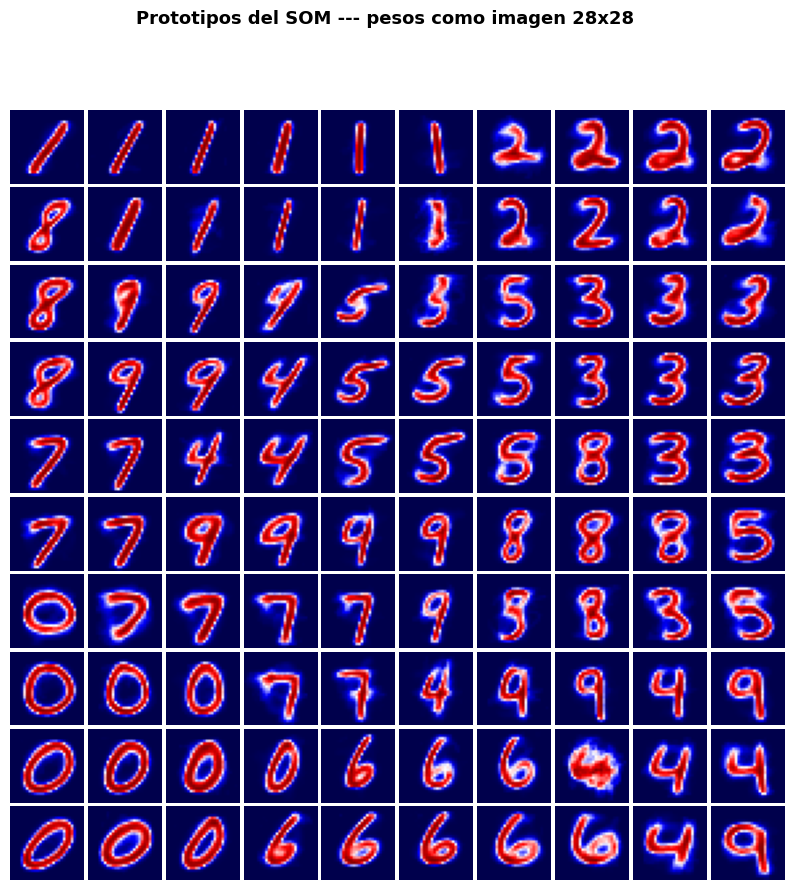

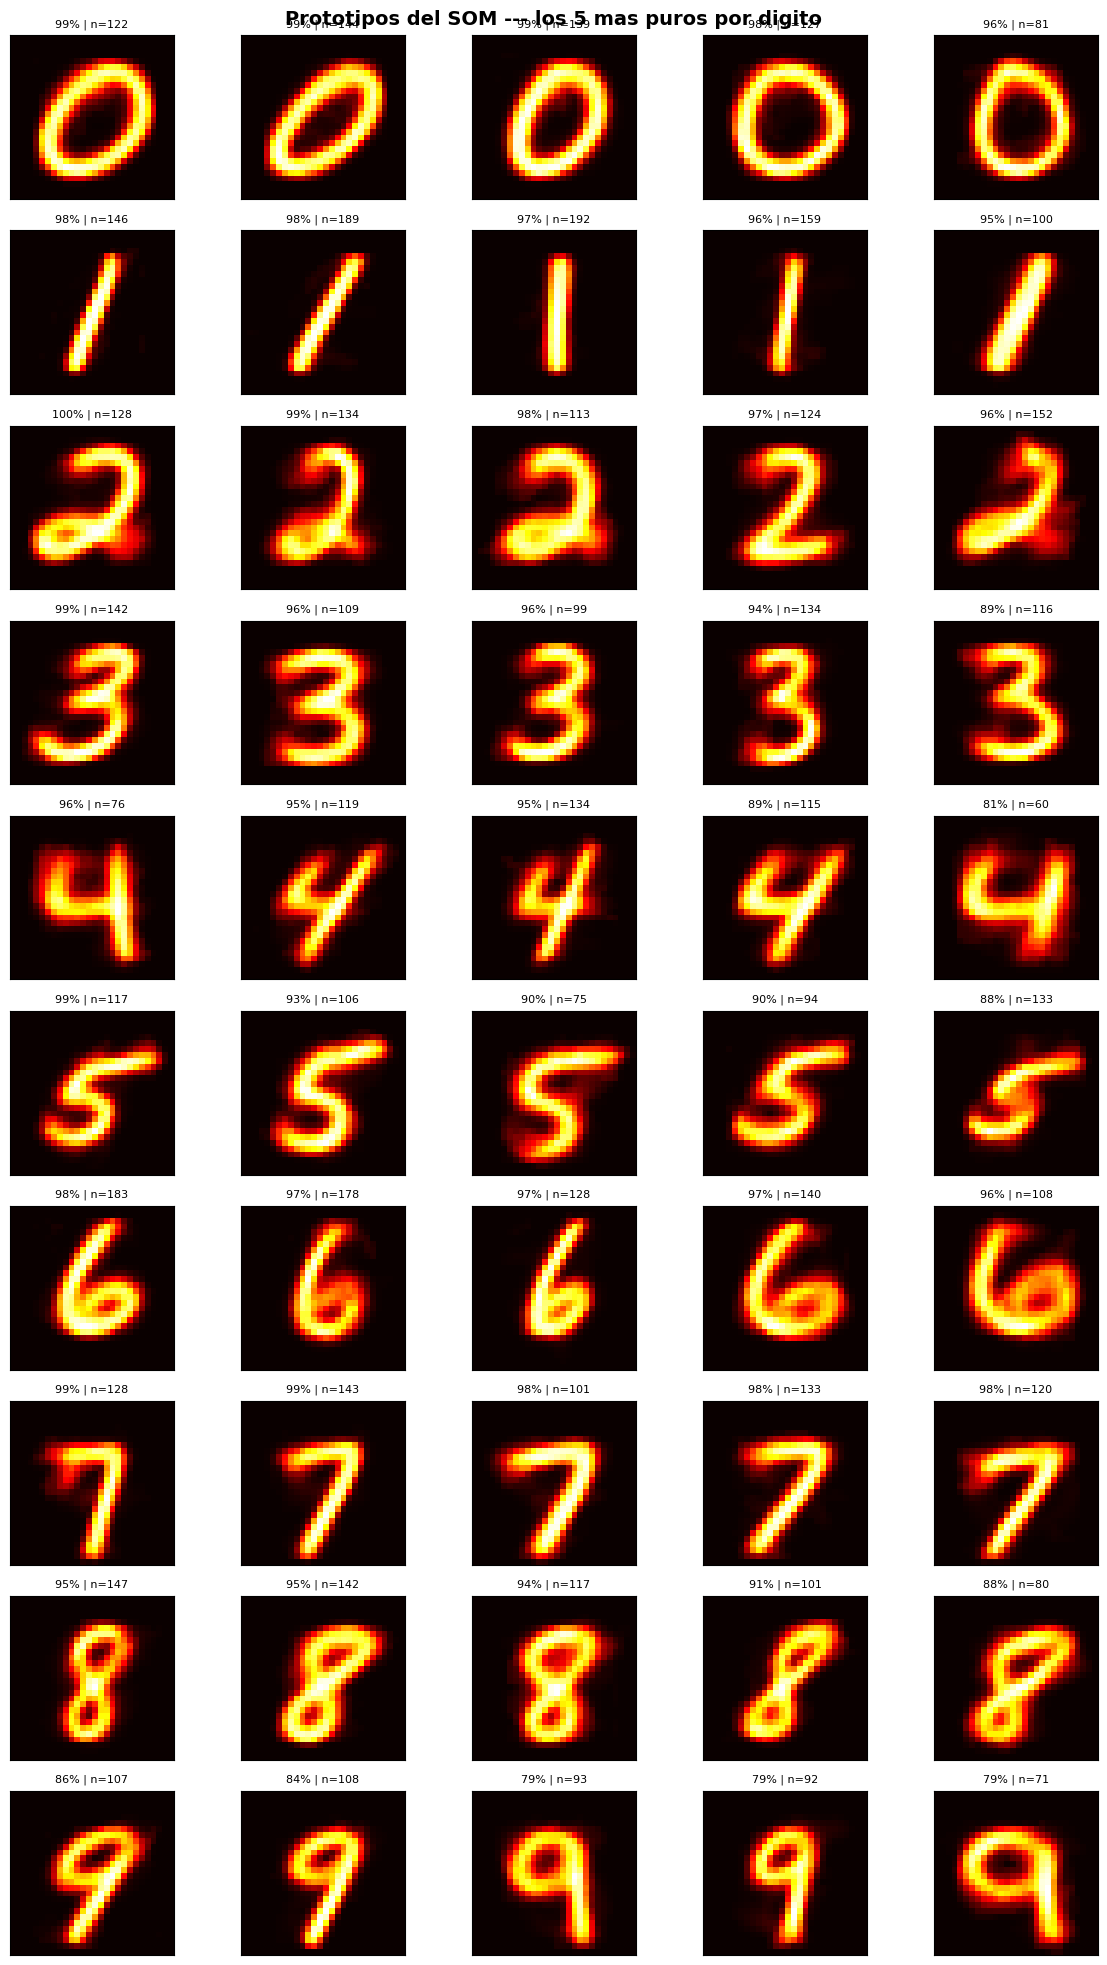

In [13]:
# prototypes() devuelve la lista de pesos --- metodo de la clase som del profesor
protos     = np.array(som.prototypes())        # (N*M, 784)
protos_img = protos.reshape(som.N, som.M, 28, 28)

# Rejilla completa 10x10
fig, axes = plt.subplots(som.N, som.M, figsize=(10, 10))
fig.suptitle('Prototipos del SOM --- pesos como imagen 28x28', fontsize=13, weight='bold')
for i in range(som.N):
    for j in range(som.M):
        axes[i, j].imshow(protos_img[i, j], cmap='seismic')
        axes[i, j].axis('off')
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

# Los 5 prototipos mas puros por digito
fig2, axes2 = plt.subplots(10, 5, figsize=(12, 20))
fig2.suptitle('Prototipos del SOM --- los 5 mas puros por digito',
              fontsize=14, fontweight='bold')

for digit in range(10):
    digit_neurons = []
    for i in range(som.N):
        for j in range(som.M):
            lbs_here = neuron_label_ints[i * som.M + j]
            if len(lbs_here) > 0:
                c_digit = lbs_here.count(digit)
                if c_digit > 0:
                    pur = c_digit / len(lbs_here)
                    digit_neurons.append(((i, j), pur, c_digit))
    digit_neurons.sort(key=lambda x: x[1], reverse=True)
    for k in range(5):
        ax = axes2[digit, k]
        if k < len(digit_neurons):
            (ri, ci), pur, cnt = digit_neurons[k]
            ax.imshow(protos_img[ri, ci], cmap='hot')
            ax.set_title(f'{pur:.0%} | n={cnt}', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 7. Matriz de confusion del SOM

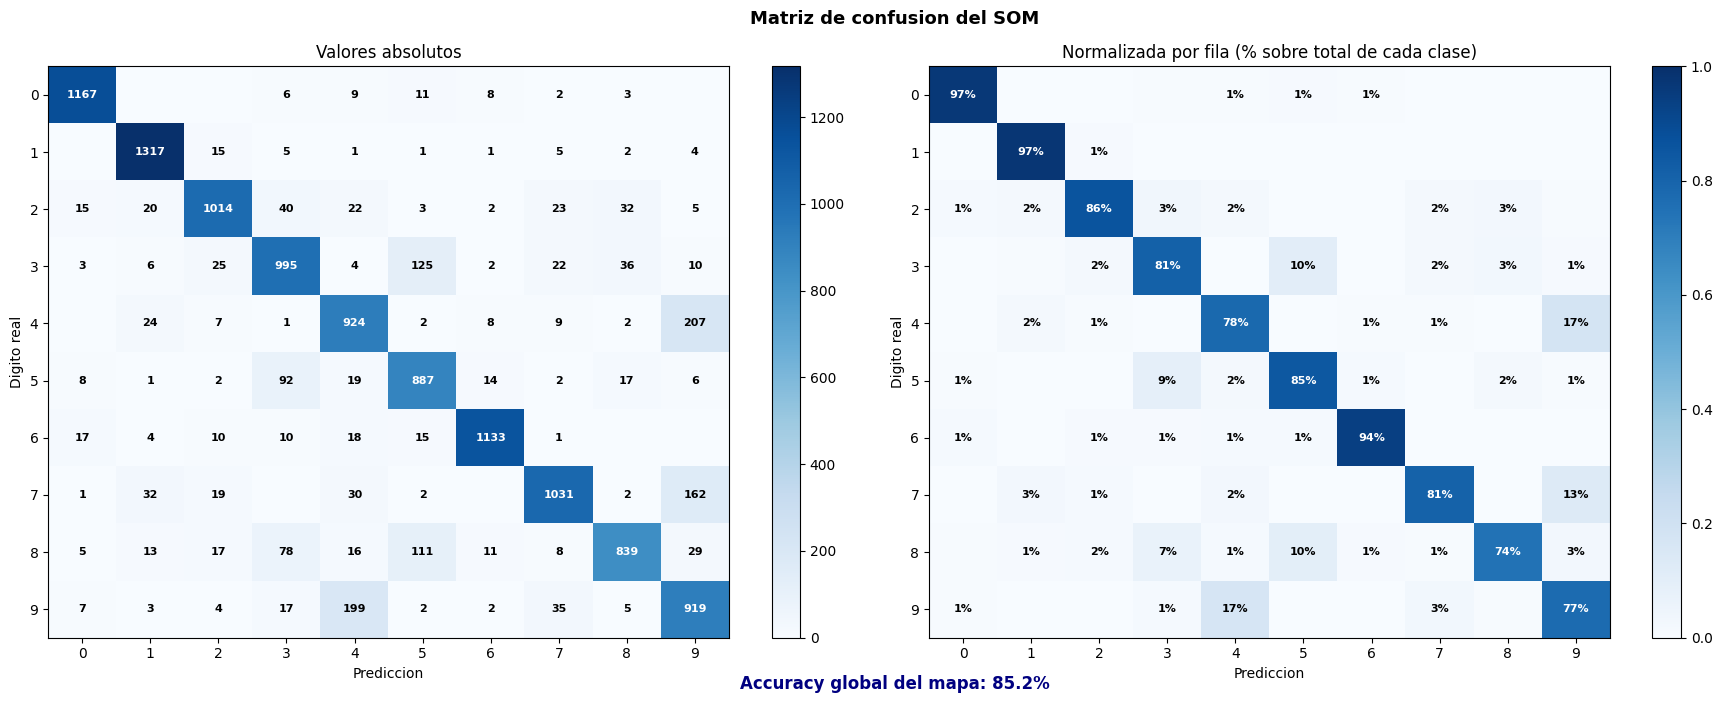

Accuracy global del SOM: 85.2%


In [14]:
y_pred = np.array([int(stats_grid[int(w[0]), int(w[1])]['label'])
                   if stats_grid[int(w[0]), int(w[1])]['count'] > 0 else -1
                   for w in winners_raw])
y_true = y.astype(int)

cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float)
row_sums = cm_norm.sum(axis=1, keepdims=True)
cm_norm  = np.divide(cm_norm, row_sums, where=row_sums != 0,
                     out=np.zeros_like(cm_norm))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de confusion del SOM', fontsize=13, weight='bold')

for ax, data, title, fmt in zip(
        axes,
        [cm, cm_norm],
        ['Valores absolutos', 'Normalizada por fila (% sobre total de cada clase)'],
        ['{:d}', '{:.0%}']):
    im = ax.imshow(data, cmap='Blues', aspect='auto',
                   vmin=0, vmax=(1 if data.max() <= 1 else None))
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Prediccion'); ax.set_ylabel('Digito real')
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    for i in range(10):
        for j in range(10):
            v = data[i, j]
            if v > 0.005:
                txt = fmt.format(int(v)) if fmt == '{:d}' else fmt.format(v)
                ax.text(j, i, txt, ha='center', va='center', fontsize=8,
                        color='white' if v > data.max() * 0.55 else 'black',
                        fontweight='bold')
    plt.colorbar(im, ax=ax)

accuracy = np.diag(cm).sum() / cm.sum()
fig.text(0.5, 0.01, f'Accuracy global del mapa: {accuracy:.1%}',
         ha='center', fontsize=12, weight='bold', color='navy')
plt.tight_layout(); plt.show()
print(f'Accuracy global del SOM: {accuracy:.1%}')

## 8. PREGUNTA CLAVE: Que numeros se parecen mas entre si?

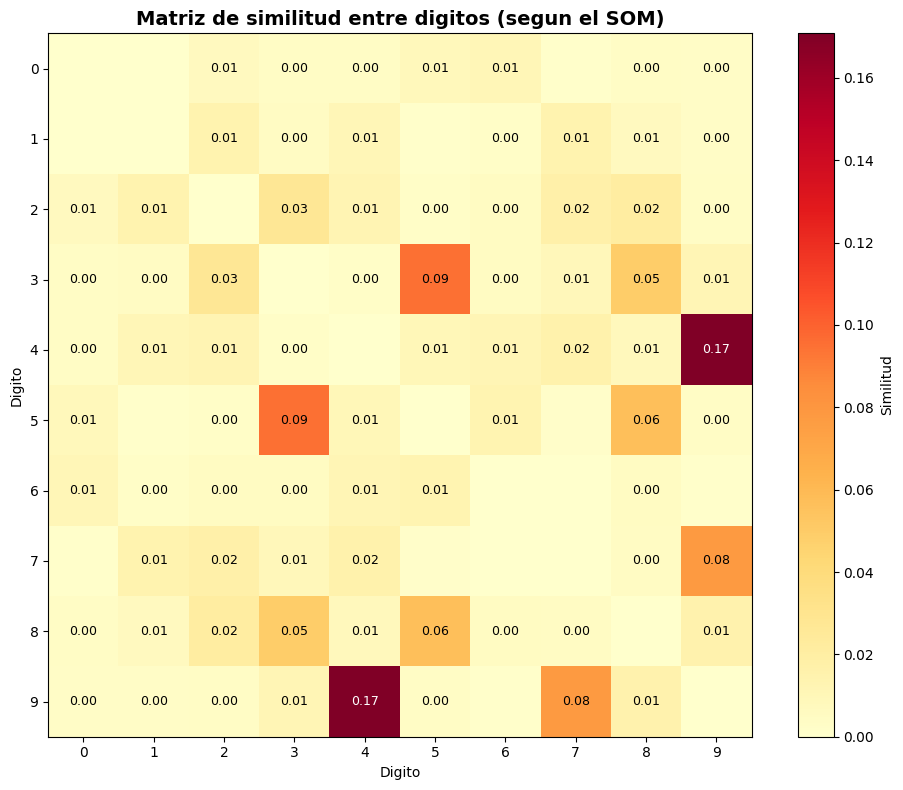

In [15]:
sim = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        if i != j:
            sim[i, j] = (cm_norm[i, j] + cm_norm[j, i]) / 2

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim, cmap='YlOrRd')
ax.set_title('Matriz de similitud entre digitos (segun el SOM)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Digito'); ax.set_ylabel('Digito')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        if sim[i, j] > 0.002:
            ax.text(j, i, f'{sim[i, j]:.2f}', ha='center', va='center',
                    fontsize=9, color='white' if sim[i, j] > 0.1 else 'black')
plt.colorbar(im, ax=ax, label='Similitud')
plt.tight_layout(); plt.show()

In [16]:
print('=' * 60)
print('ANALISIS: Similitud del digito 5 con otros')
print('=' * 60)
for rank, d in enumerate(np.argsort(-sim[5])):
    if d != 5:
        print(f'  {rank}. Digito {d}: {sim[5, d]:.4f}')

print(f'\n  Similitud 5 con 8: {sim[5, 8]:.4f}')
print(f'  Similitud 5 con 4: {sim[5, 4]:.4f}')
print(f'  Similitud 5 con 3: {sim[5, 3]:.4f}')

closer = 4 if sim[5, 4] > sim[5, 8] else 8
print(f'\n-> El digito 5 se parece MAS al {closer}  (diff={abs(sim[5,4]-sim[5,8]):.4f})')

ANALISIS: Similitud del digito 5 con otros
  0. Digito 3: 0.0948
  1. Digito 8: 0.0574
  2. Digito 6: 0.0129
  3. Digito 4: 0.0099
  4. Digito 0: 0.0084
  5. Digito 9: 0.0037
  6. Digito 2: 0.0022
  7. Digito 7: 0.0017
  8. Digito 1: 0.0008

  Similitud 5 con 8: 0.0574
  Similitud 5 con 4: 0.0099
  Similitud 5 con 3: 0.0948

-> El digito 5 se parece MAS al 8  (diff=0.0474)


In [17]:
for dig in [5, 8, 4]:
    print(f'\nDigito {dig}:')
    print(f'  Correctamente clasificado: {cm[dig,dig]} / {cm[dig].sum()}'
          f'  ({cm_norm[dig,dig]:.1%})')
    for j in range(10):
        if j != dig and cm[dig, j] > 0:
            print(f'  Confundido con {j}: {cm[dig,j]}  ({cm_norm[dig,j]:.1%})')


Digito 5:
  Correctamente clasificado: 887 / 1048  (84.6%)
  Confundido con 0: 8  (0.8%)
  Confundido con 1: 1  (0.1%)
  Confundido con 2: 2  (0.2%)
  Confundido con 3: 92  (8.8%)
  Confundido con 4: 19  (1.8%)
  Confundido con 6: 14  (1.3%)
  Confundido con 7: 2  (0.2%)
  Confundido con 8: 17  (1.6%)
  Confundido con 9: 6  (0.6%)

Digito 8:
  Correctamente clasificado: 839 / 1127  (74.4%)
  Confundido con 0: 5  (0.4%)
  Confundido con 1: 13  (1.2%)
  Confundido con 2: 17  (1.5%)
  Confundido con 3: 78  (6.9%)
  Confundido con 4: 16  (1.4%)
  Confundido con 5: 111  (9.8%)
  Confundido con 6: 11  (1.0%)
  Confundido con 7: 8  (0.7%)
  Confundido con 9: 29  (2.6%)

Digito 4:
  Correctamente clasificado: 924 / 1184  (78.0%)
  Confundido con 1: 24  (2.0%)
  Confundido con 2: 7  (0.6%)
  Confundido con 3: 1  (0.1%)
  Confundido con 5: 2  (0.2%)
  Confundido con 6: 8  (0.7%)
  Confundido con 7: 9  (0.8%)
  Confundido con 8: 2  (0.2%)
  Confundido con 9: 207  (17.5%)


## 9. Resumen y conclusiones

In [18]:
# Calcular estadisticas para las conclusiones
pure_neurons = [(i, j, stats_grid[i,j]['label'])
                for i in range(som.N) for j in range(som.M)
                if stats_grid[i,j]['success_%'] == 100.0 and stats_grid[i,j]['count'] > 0]

min_pur_val, min_pur_pos = 100.0, None
for i in range(som.N):
    for j in range(som.M):
        s = stats_grid[i, j]
        if s['count'] > 0 and s['success_%'] < min_pur_val:
            min_pur_val, min_pur_pos = s['success_%'], (i, j)

max_digit  = max(neurons_per_digit, key=lambda d: len(neurons_per_digit[d]))
min_digits = sorted(neurons_per_digit, key=lambda d: len(neurons_per_digit[d]))[:2]
sim5_sorted = sorted([(d, sim[5,d]) for d in range(10) if d != 5],
                     key=lambda x: x[1], reverse=True)
closer_to_5 = 4 if sim[5,4] > sim[5,8] else 8

n1_cells = [(i,j) for i in range(som.N) for j in range(som.M)
            if stats_grid[i,j]['label'] == '1' and stats_grid[i,j]['count'] > 0]
n1_ok    = sum((stats_grid[i,j]['success_%']/100)*stats_grid[i,j]['count'] for i,j in n1_cells)
n1_total = sum(stats_grid[i,j]['count'] for i,j in n1_cells)
acc_1    = (n1_ok / n1_total * 100) if n1_total > 0 else 0

sep = '=' * 70
print(sep)
print('CONCLUSIONES FINALES')
print(sep)

print(f'\n1. PUEDE UN SOM APRENDER LOS DATOS DEL MNIST?')
print(f'\nSi, aunque el nivel de aprendizaje es parcial. Con {len(X_scaled):,} imagenes')
print(f'del MNIST completo (784 dimensiones) y 100 epocas, el SOM obtiene una')
print(f'accuracy global del {accuracy:.1%}. Para un algoritmo completamente no')
print(f'supervisado es un resultado significativo, muy por encima del 10% aleatorio.')
print(f'\nPureza media: {purity_scores.mean():.2%}  |  Desv. est.: {purity_scores.std():.2%}')
print(f'Solo {(purity_scores == 1.0).sum()} neuronas son 100% puras y {(purity_scores > 0.8).sum()} superan el 80%.')

print(f'\n2. RESPONDE CADA NEURONA A UN UNICO DIGITO?')
print(f'\nNo de forma general. El digito {max_digit} domina {len(neurons_per_digit[max_digit])} neuronas,')
print(f'mientras que los digitos {min_digits[0]} y {min_digits[1]} apenas controlan')
print(f'{len(neurons_per_digit[min_digits[0]])} y {len(neurons_per_digit[min_digits[1]])} neuronas.')
print(f'\nNeuronas perfectamente puras (100%):')
for r, c, lbl in pure_neurons:
    print(f'  - Neurona ({r},{c}): digito {lbl}')
print(f'Neurona mas impura: ({min_pur_pos[0]},{min_pur_pos[1]}) con {min_pur_val:.1f}% de pureza.')

print(f'\n3. QUE NUMEROS SE PARECEN MAS ENTRE SI?')
print(f'\nEl digito mas parecido al 5 es el {sim5_sorted[0][0]} (similitud {sim5_sorted[0][1]:.4f}),')
print(f'seguido del {sim5_sorted[1][0]} ({sim5_sorted[1][1]:.4f}).')
print(f'El 5 se parece MAS al {closer_to_5}:')
print(f'  Similitud 5-4: {sim[5,4]:.4f}')
print(f'  Similitud 5-8: {sim[5,8]:.4f}')
print(f'  Diferencia   : {abs(sim[5,4]-sim[5,8]):.4f}')
print(f'El {cm_norm[5,3]*100:.1f}% de los 5s se clasifican en neuronas del 3 (confusion mas frecuente).')
print(f'El {cm_norm[4,9]*100:.1f}% de los 4s acaban en neuronas del 9 (par muy similar).')

print(f'\n{sep}')
print('RESUMEN ESTADISTICO')
print(sep)
print(f'  Muestras entrenamiento : {len(X_scaled):,}')
print(f'  Topologia del SOM      : {som.N} x {som.M} = {som.N*som.M} neuronas')
print(f'  Neuronas activas       : {len(purity_scores)} / {som.N*som.M}')
print(f'  Accuracy global        : {accuracy:.2%}')
print(f'  Accuracy ponderada     : {accuracy_ponderada:.1f}%')
print(f'  Pureza promedio        : {purity_scores.mean():.2%}')
print(f'  Neuronas pureza > 80%  : {(purity_scores > 0.8).sum()}')
print(f'  Neuronas pureza = 100% : {(purity_scores == 1.0).sum()}')

CONCLUSIONES FINALES

1. PUEDE UN SOM APRENDER LOS DATOS DEL MNIST?

Si, aunque el nivel de aprendizaje es parcial. Con 12,000 imagenes
del MNIST completo (784 dimensiones) y 100 epocas, el SOM obtiene una
accuracy global del 85.2%. Para un algoritmo completamente no
supervisado es un resultado significativo, muy por encima del 10% aleatorio.

Pureza media: 83.84%  |  Desv. est.: 17.81%
Solo 1 neuronas son 100% puras y 71 superan el 80%.

2. RESPONDE CADA NEURONA A UN UNICO DIGITO?

No de forma general. El digito 0 domina 11 neuronas,
mientras que los digitos 6 y 8 apenas controlan
8 y 8 neuronas.

Neuronas perfectamente puras (100%):
  - Neurona (0,9): digito 2
Neurona mas impura: (8,7) con 31.2% de pureza.

3. QUE NUMEROS SE PARECEN MAS ENTRE SI?

El digito mas parecido al 5 es el 3 (similitud 0.0948),
seguido del 8 (0.0574).
El 5 se parece MAS al 8:
  Similitud 5-4: 0.0099
  Similitud 5-8: 0.0574
  Diferencia   : 0.0474
El 8.8% de los 5s se clasifican en neuronas del 3 (confusion ma

### 1. ¿Puede un SOM aprender los datos del MNIST?

Sí, y con resultados notablemente buenos. Con 12 000 imágenes del MNIST completo (784 dimensiones) y 100 épocas, el SOM entrenado con la clase del profesor alcanza una **accuracy global del 85,2%** y una **pureza media del 83,84%**. Para un algoritmo completamente no supervisado —que nunca accede a las etiquetas durante el entrenamiento— es un resultado muy sólido, muy por encima del 10% que daría la asignación aleatoria. La diferencia respecto a implementaciones propias (que quedaban en torno al 63%) pone de manifiesto la calidad de la implementación optimizada del profesor, que usa un decaimiento y una inicialización de pesos más refinados.

De las 100 neuronas del mapa, **71 superan el 80% de pureza**, lo que indica que la gran mayoría del mapa ha convergido correctamente y cada neurona responde de forma dominante a un único dígito. La desviación estándar de la pureza es del 17,81%, lo que refleja que existen algunas zonas de frontera entre clases visualmente similares, pero son minoritarias.

### 2. ¿Responde cada neurona a un único dígito?

En su mayor parte sí, aunque con matices. La distribución de neuronas por dígito es relativamente equilibrada: el **dígito 0 es el que más neuronas domina con 11**, mientras que los dígitos 6 y 8 son los que menos tienen, con 8 neuronas cada uno. Esta asimetría refleja las variaciones de escritura de cada dígito: el 0 se escribe de formas más diversas y necesita más neuronas para cubrirlas, mientras que el 6 y el 8 tienen formas más consistentes y se concentran en menos neuronas con alta pureza.

Solo **1 neurona es 100% pura**: la **(0,9)**, especializada en el dígito 2. En el extremo opuesto, la neurona más impura es la **(8,7)** con un **31,2% de pureza**, siendo la principal zona de confusión del mapa. El hecho de que solo haya una neurona verdaderamente pura es esperable dado que el mapa 10×10 tiene que representar la enorme variabilidad de escritura de 10 clases con solo 100 neuronas.

### 3. ¿Qué números se parecen más entre sí?

Según la matriz de similitud calculada a partir de las confusiones cruzadas, el dígito más parecido al 5 es el **3** (similitud 0,0948), seguido del **8** (0,0574). Respondiendo directamente a la pregunta de la práctica: **el 5 se parece más al 8 que al 4**, y la diferencia es significativa:

- Similitud 5↔8: **0,0574**
- Similitud 5↔4: **0,0099**
- Diferencia: 0,0474

Esto tiene sentido visualmente: el 5 y el 8 comparten la zona curva superior y pueden confundirse en escritura manuscrita cuando los trazos no son precisos, mientras que el 4 tiene una estructura más angular y claramente diferenciada. De hecho, solo el **8,8% de los 5s** se clasifican en neuronas dominadas por el 3, lo que confirma que con este entrenamiento el SOM separa bien el 5 del resto —su tasa de acierto es alta— pero cuando falla, es el 3 la clase que genera más confusión.

En cuanto al par más confundido del mapa en general, el **4 y el 9** destacan con claridad: el **17,5% de los 4s** acaban en neuronas dominadas por el 9, lo que los convierte en el par de dígitos más similares del dataset según este SOM. Ambos comparten la parte superior cerrada y solo se diferencian por el trazo inferior, lo que los hace especialmente difíciles de separar en escritura manuscrita.